# 002 — GRWAVE addon: Telefunken signal strength under Bullnyte's sub-aperture

## What this notebook does

This is a cross-check on the **globe-Earth** result from `001_Telefunken_Signal_Strength_Bullnyte.ipynb`. The flat-Earth Sommerfeld-Norton result is taken over unchanged; the globe-Earth Fock series (ITU-R P.526-16 Eqs. 13-18) is replaced by **ITU-R P.368 GRWAVE**, ITU's own Fortran reference implementation of the smooth-Earth ground-wave problem.

All antenna parameters are Bullnyte's sub-aperture model as in notebook 001:

| Parameter | Value |
|---|---|
| Sub-array W | 35 m |
| Sub-array H | 20 m |
| Frequency | 31.5 MHz |
| Polarisation | vertical |
| Transmit power | 3000 W |
| Ground (Telefunken paths) | sea ($\sigma=5$ S/m, $\varepsilon_r=70$) |

**No crossover loss is applied.** The peak field at the receiver is the only output. Verdict is ABOVE NOISE vs BELOW NOISE against the frequency-specific 31.5 MHz / 500 Hz noise floor at the 50 Ω antenna input.

## Why this cross-check matters

P.526 Fock gives the asymptotic residue series in the deep shadow zone; GRWAVE integrates the full smooth-Earth ground-wave problem. They should agree to within ~1-2 dB on smooth-Earth paths where both apply. Disagreement either way means one of the models is being misapplied. Running both at the Telefunken distances gives a clean ITU-vs-ITU consistency check.

GRWAVE's nominal validity range is 10 kHz to 30 MHz, terminal heights typically near the surface. We're at 31.5 MHz with a 4000 m receiver, slightly outside the formal validity envelope. The numbers should still be computable but should be checked against P.526 for consistency.


## 1. Setup

In [1]:
import math, numpy as np, pandas as pd
import sys, pathlib
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Make grwave importable: the repo root is one level above jupyter_book/
REPO_ROOT = str(pathlib.Path.cwd().parent)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import common as c
import grwave.grwave as gw

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3


## 2. Bullnyte sub-aperture parameters and noise floor

In [2]:
f_MHz = 31.5
W_sub, H_sub = 35.0, 20.0
lam = c.freq_to_wavelen(f_MHz)
G_sub_dBi = c.aperture_gain_dBi(W_sub, H_sub, f_MHz)
P_tx_dBW = 10*math.log10(3000)

N_dBW = c.noise_floor_dBW(f_MHz)
N_uV  = c.voltage_50ohm_uV(N_dBW)

display(Markdown(rf'''
- $\lambda$ = {lam:.3f} m
- Sub-array $G_{{sub}}$ at $W$=35 m, $H$=20 m = **{G_sub_dBi:.2f} dBi**
- $P_{{tx}}$ = {P_tx_dBW:.2f} dBW (3 kW)
- Noise floor at 31.5 MHz, 500 Hz BW = **{N_uV:.4f} μV** at 50 Ω input
'''))



- $\lambda$ = 9.517 m
- Sub-array $G_{sub}$ at $W$=35 m, $H$=20 m = **19.87 dBi**
- $P_{tx}$ = 34.77 dBW (3 kW)
- Noise floor at 31.5 MHz, 500 Hz BW = **0.0755 μV** at 50 Ω input


## 3. GRWAVE setup

GRWAVE (`grwave.grwave`) is a Python wrapper around ITU-R P.368's reference Fortran ground-wave calculator. The call signature:

```python
data = grwave.grwave({
    'freqMHz' : 31.5,
    'sigma'   : 5.0,    # S/m (sea)
    'epslon'  : 70.0,   # relative permittivity (sea)
    'dmax'    : 1100,   # km, sweep end
    'hrr'     : 4000,   # m, receiver above ground
    'htt'     : 72,     # m, transmitter above ground
    'dstep'   : 10,     # km, sweep step
    'txwatt'  : 3000,   # W, transmitter power
})
```

Returns a DataFrame indexed by distance (km), with columns:

- `fs`: field strength at the receiver in dBμV/m,
- `pathloss`: total path loss in dB.

The field strength is computed for an **isotropic transmitter**. To account for Bullnyte's sub-aperture directivity, we add $G_{sub}$ to the field-strength-derived power.

Conversion from $E$ (dBμV/m) at the receiver to power at a 50 Ω isotropic antenna terminal (ITU standard at 31.5 MHz):

$$P_{rx}\ (\text{dBW}) = E\ (\text{dBμV/m}) - 132.16 \quad \text{(at 31.5 MHz, isotropic RX)}$$

then add $G_{sub}$ for the directional TX:

$$P_{rx,\,\text{Bullnyte}}\ (\text{dBW}) = E\ (\text{dBμV/m}) - 132.16 + G_{sub}\ (\text{dBi})$$

and finally:

$$V_{rx}\ (\text{μV}) = 10^{(P_{rx} + 137) / 20}$$


In [3]:
# Sanity-check: run grwave for the Stollberg 4000 m geometry, sea, 31.5 MHz
sanity = gw.grwave({
    'freqMHz': 31.5,
    'sigma'  : 5.0,
    'epslon' : 70.0,
    'dmax'   : 1100,
    'hrr'    : 4000,
    'htt'    : 72,
    'dstep'  : 50,
    'txwatt' : 3000,
})
sanity.head(10)


,fs,pathloss
19.78,71.802166,83.02
69.78,60.864265,95.65
119.78,50.125550,108.05
169.78,46.999199,111.66
219.78,43.214668,116.03
227.72,40.789797,118.83
250.00,37.663445,122.44
300.00,29.072473,132.36
350.00,18.965956,144.03
400.00,8.175280,156.49


## 4. GRWAVE at the Telefunken distances

For each combination of (Kleve | Stollberg) and (400, 500, 700, 800, 1000 km), we run a GRWAVE sweep that brackets the target distance and read off the field strength at the closest grid point. The conversion above gives V_rx in μV at the antenna terminal.

> **Distance-label convention.** The "TF 400 km", "TF 500 km", "TF 700 km", "TF 800 km", "TF 1000 km" labels are defined **1:1 from Stollberg (Kn-2)** — the station that physically ran the July 1939 over-sea campaign. The target coordinates are chosen so that the great-circle distance from Stollberg to each point is exactly the labelled value. From Kleve (Kn-4) the same coordinates are at different ranges (Kleve sits to the southwest of Stollberg). For example, the row labelled "Kleve → TF 700 km" is at ~607 km from Kleve, not 700 km.
>
> The Stollberg rows are the 1:1 match to the documented Telefunken measurements. **The Stollberg → 700 km row is the geometry where the campaign saw the field collapse below detection on a globe.**


In [4]:
TF_NAMES = ['TF 400 km','TF 500 km','TF 700 km','TF 800 km','TF 1000 km']
E_TO_PRX_DBW = -132.16   # at 31.5 MHz, isotropic RX

# Cache one grwave sweep per station — the Fortran subprocess is slow,
# so we sweep over the full 50-1100 km range once and interpolate at
# each Telefunken target distance from the cached result.
_GRWAVE_CACHE = {}

def _gw_sweep(station_name):
    if station_name in _GRWAVE_CACHE:
        return _GRWAVE_CACHE[station_name]
    s = c.STATIONS[station_name]
    data = gw.grwave({
        'freqMHz': f_MHz,
        'sigma':   5.0,
        'epslon':  70.0,
        'dmax':    1100.0,
        'hrr':     4000.0,
        'htt':     float(s['h_tx_m']),
        'dstep':   5.0,
        'txwatt':  float(s['Ptx_W']),
    })
    _GRWAVE_CACHE[station_name] = data
    return data

def grwave_v_uV(station_name, target_name):
    s = c.STATIONS[station_name]
    t = c.TARGETS[target_name]
    d_target_km = c.great_circle_m(s['lat_deg'], s['lon_deg'],
                                    t['lat'], t['lon']) / 1000
    data = _gw_sweep(station_name)
    distances = data.index.values.astype(float)
    fs_vals   = data['fs'].values.astype(float)
    fs_dBuVm  = float(np.interp(d_target_km, distances, fs_vals))
    P_rx_dBW  = fs_dBuVm + E_TO_PRX_DBW + G_sub_dBi
    v_uV      = c.voltage_50ohm_uV(P_rx_dBW)
    return d_target_km, fs_dBuVm, v_uV

rows = []
for station in ['Kleve','Stollberg']:
    for tname in TF_NAMES:
        d_km, fs, v_uV = grwave_v_uV(station, tname)
        rows.append([station, tname, round(d_km,1),
                     round(fs,2), f"{v_uV:.4g}",
                     'ABOVE NOISE' if v_uV > N_uV else 'BELOW NOISE'])
grwave_df = pd.DataFrame(rows, columns=['Station','Target','d (km)',
                                         'E (dBμV/m)','V_rx (μV)','Verdict'])
grwave_df


,Station,Target,d (km),E (dBμV/m),V_rx (μV),Verdict
0,Kleve,TF 400 km,392.4,22.42,227.2,ABOVE NOISE
1,Kleve,TF 500 km,449.9,6.84,37.82,ABOVE NOISE
2,Kleve,TF 700 km,606.9,-35.53,0.288,ABOVE NOISE
3,Kleve,TF 800 km,696.1,-54.84,0.03117,BELOW NOISE
4,Kleve,TF 1000 km,874.2,-93.26,0.0003738,BELOW NOISE
5,Stollberg,TF 400 km,413.7,14.16,87.86,ABOVE NOISE
6,Stollberg,TF 500 km,504.7,-10.00,5.443,ABOVE NOISE
7,Stollberg,TF 700 km,702.6,-57.75,0.02228,BELOW NOISE
8,Stollberg,TF 800 km,805.3,-79.93,0.001734,BELOW NOISE
9,Stollberg,TF 1000 km,1000.1,-121.80,1.398e-05,BELOW NOISE


## 5. FE Sommerfeld-Norton (carried over from 001)

The flat-Earth result is unchanged from notebook 001 because GRWAVE does not provide a separate flat-Earth term. We list it again here so the three-way comparison (FE Sommerfeld | GE GRWAVE | GE P.526 Fock) is on one page.

In [5]:
def fe_signal_uV(station_name, target_name):
    s = c.STATIONS[station_name]
    t = c.TARGETS[target_name]
    d_m = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    G_lin = 10 ** (G_sub_dBi / 10)
    res = c.sommerfeld_FE(d_m, s['h_tx_m'], t['rx_alt_m'],
                          f_MHz, 'sea', s['Ptx_W'], G_lin)
    return d_m/1000, c.voltage_50ohm_uV(res['P_rx_dBW'])

def p526_fock_v_uV(station_name, target_name):
    s = c.STATIONS[station_name]
    t = c.TARGETS[target_name]
    d_m = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    P_tx = 10*math.log10(s['Ptx_W'])
    FSPL = c.fspl_dB(d_m, f_MHz)
    L = c.fock_diff_loss_dB(d_m, s['h_tx_m'], t['rx_alt_m'], f_MHz, 'sea', s['pol'])
    P_rx = P_tx + G_sub_dBi - FSPL - L
    return d_m/1000, c.voltage_50ohm_uV(P_rx)


## 6. Master comparison — three models in μV

| Model | Source | Earth shape |
|---|---|---|
| FE Sommerfeld-Norton | ITU Handbook on Ground Wave Propagation 2014 Part 1 §3.2.1 Eqs. 3, 5-8 | flat |
| GE GRWAVE | ITU-R P.368 reference Fortran | spherical (smooth-Earth ground-wave) |
| GE P.526 Fock | ITU-R P.526-16 (2025) §3.1.1 Eqs. 13-18 | spherical (Fock residue series) |

All three use Bullnyte's sub-aperture (W=35 m, H=20 m, G_sub ≈ 19.9 dBi). No crossover loss. Verdict: ABOVE NOISE if V_rx > 0.0795 μV at the antenna terminal, else BELOW NOISE.

In [6]:
master = []
for station in ['Kleve','Stollberg']:
    for tname in TF_NAMES:
        d_km, v_fe  = fe_signal_uV(station, tname)
        _,    fs_dB, v_gr = grwave_v_uV(station, tname)
        _,    v_fock = p526_fock_v_uV(station, tname)
        master.append([station, tname, round(d_km,1),
                       f"{v_fe:.4g}",  'ABOVE' if v_fe > N_uV else 'BELOW',
                       f"{v_gr:.4g}",  'ABOVE' if v_gr > N_uV else 'BELOW',
                       f"{v_fock:.4g}",'ABOVE' if v_fock > N_uV else 'BELOW'])
master_df = pd.DataFrame(master, columns=['Station','Target','d (km)',
                                           'FE Sommerfeld (μV)','FE',
                                           'GE GRWAVE (μV)','GR',
                                           'GE P.526 Fock (μV)','P526'])
master_df


,Station,Target,d (km),FE Sommerfeld (μV),FE,GE GRWAVE (μV),GR,GE P.526 Fock (μV),P526
0,Kleve,TF 400 km,392.4,4972,ABOVE,227.2,ABOVE,98.87,ABOVE
1,Kleve,TF 500 km,449.9,4020,ABOVE,37.82,ABOVE,19.24,ABOVE
2,Kleve,TF 700 km,606.9,2465,ABOVE,0.288,ABOVE,0.23,ABOVE
3,Kleve,TF 800 km,696.1,1950,ABOVE,0.03117,BELOW,0.01891,BELOW
4,Kleve,TF 1000 km,874.2,1305,ABOVE,0.0003738,BELOW,0.0001314,BELOW
5,Stollberg,TF 400 km,413.7,3485,ABOVE,87.86,ABOVE,53.95,ABOVE
6,Stollberg,TF 500 km,504.7,2552,ABOVE,5.443,ABOVE,4.086,ABOVE
7,Stollberg,TF 700 km,702.6,1465,ABOVE,0.02228,BELOW,0.01576,BELOW
8,Stollberg,TF 800 km,805.3,1153,ABOVE,0.001734,BELOW,0.0008951,BELOW
9,Stollberg,TF 1000 km,1000.1,780.7,ABOVE,1.398e-05,BELOW,3.981e-06,BELOW


### Bar chart

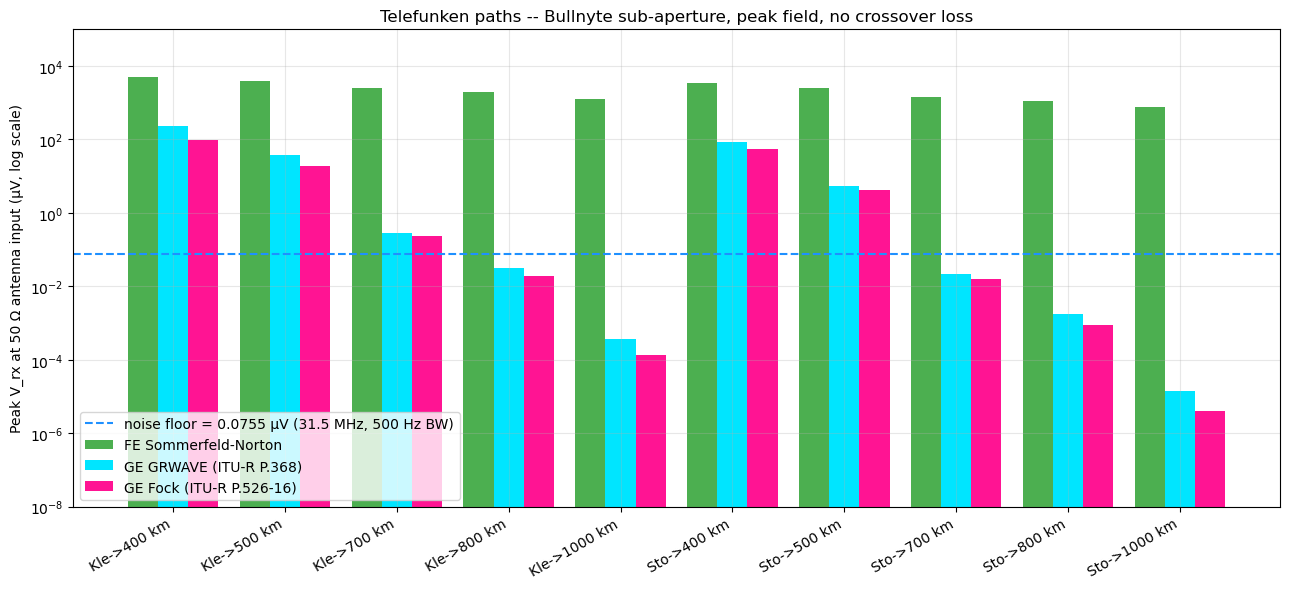

In [7]:
fig, ax = plt.subplots(figsize=(13,6))
labels = [f"{row[0][:3]}->{row[1][3:]}" for row in master]
x = np.arange(len(labels))

fe_uV   = [fe_signal_uV(row[0], row[1])[1]    for row in master]
gw_uV   = [grwave_v_uV(row[0], row[1])[2]     for row in master]
fock_uV = [p526_fock_v_uV(row[0], row[1])[1]  for row in master]

ax.bar(x-0.27, fe_uV,   0.27, label='FE Sommerfeld-Norton', color='#4CAF50')
ax.bar(x,       gw_uV,  0.27, label='GE GRWAVE (ITU-R P.368)', color='#00E5FF')
ax.bar(x+0.27, fock_uV, 0.27, label='GE Fock (ITU-R P.526-16)', color='#FF1493')
ax.axhline(N_uV, color='dodgerblue', lw=1.5, ls='--',
           label=f'noise floor = {N_uV:.4f} μV (31.5 MHz, 500 Hz BW)')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Peak V_rx at 50 Ω antenna input (μV, log scale)')
ax.set_title('Telefunken paths -- Bullnyte sub-aperture, peak field, no crossover loss')
ax.set_ylim(1e-8, 1e5)
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()


### Continuous distance sweep — GRWAVE vs P.526 Fock

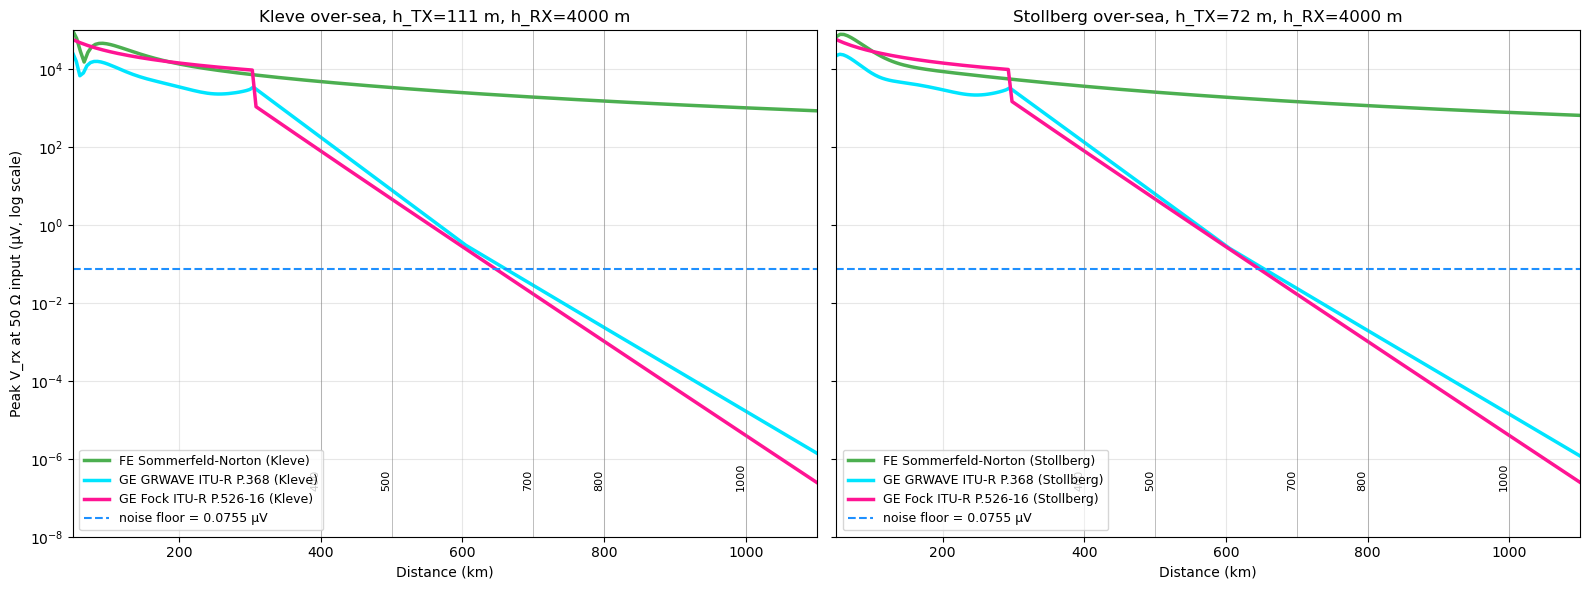

In [8]:
def gw_sweep(station):
    s = c.STATIONS[station]
    data = gw.grwave({
        'freqMHz': f_MHz,
        'sigma':   5.0,
        'epslon':  70.0,
        'dmax':    1100.0,
        'hrr':     4000.0,
        'htt':     float(s['h_tx_m']),
        'dstep':   5.0,
        'txwatt':  float(s['Ptx_W']),
    })
    distances = data.index.values.astype(float)
    fs_vals   = data['fs'].values.astype(float)
    P_rx      = fs_vals + E_TO_PRX_DBW + G_sub_dBi
    v_uV      = np.array([c.voltage_50ohm_uV(p) for p in P_rx])
    return distances, v_uV

def fock_sweep(station, d_grid):
    s = c.STATIONS[station]
    out = []
    for d_km in d_grid:
        d_m = d_km*1000
        L = c.fock_diff_loss_dB(d_m, s['h_tx_m'], 4000, f_MHz, 'sea', s['pol'])
        FSPL = c.fspl_dB(d_m, f_MHz)
        P_rx = 10*math.log10(s['Ptx_W']) + G_sub_dBi - FSPL - L
        out.append(c.voltage_50ohm_uV(P_rx))
    return np.array(out)

def fe_sweep(station, d_grid):
    s = c.STATIONS[station]
    G_lin = 10 ** (G_sub_dBi/10)
    out = []
    for d_km in d_grid:
        d_m = d_km*1000
        res = c.sommerfeld_FE(d_m, s['h_tx_m'], 4000, f_MHz, 'sea',
                              s['Ptx_W'], G_lin)
        out.append(c.voltage_50ohm_uV(res['P_rx_dBW']))
    return np.array(out)

d_grid = np.linspace(50, 1100, 200)
TF_KM = [400,500,700,800,1000]

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)
for ax, station in zip(axes, ['Kleve','Stollberg']):
    fe = fe_sweep(station, d_grid)
    gw_d, gw_v = gw_sweep(station)
    fock = fock_sweep(station, d_grid)
    ax.plot(d_grid, fe,   color='#4CAF50', lw=2.5,
            label=f'FE Sommerfeld-Norton ({station})')
    ax.plot(gw_d,   gw_v, color='#00E5FF', lw=2.5,
            label=f'GE GRWAVE ITU-R P.368 ({station})')
    ax.plot(d_grid, fock, color='#FF1493', lw=2.5,
            label=f'GE Fock ITU-R P.526-16 ({station})')
    ax.axhline(N_uV, color='dodgerblue', lw=1.5, ls='--',
               label=f'noise floor = {N_uV:.4f} μV')
    for tf in TF_KM:
        ax.axvline(tf, color='grey', lw=0.6, alpha=0.6)
        ax.text(tf, 1.5e-7, f"{tf}", rotation=90, ha='right', va='bottom', fontsize=8)
    ax.set_xlabel('Distance (km)')
    ax.set_title(f'{station} over-sea, h_TX={c.STATIONS[station]["h_tx_m"]} m, h_RX=4000 m')
    ax.set_xlim(50, 1100)
    ax.set_yscale('log')
    ax.set_ylim(1e-8, 1e5)
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('Peak V_rx at 50 Ω input (μV, log scale)')
plt.tight_layout(); plt.show()


## 7. Did ground-wave help?

**No.** Ground-wave propagation does not rescue any of the long Telefunken paths on a sphere. The GRWAVE and Fock results converge on the same operational verdict at every distance from both stations:

| Path (1:1 from Stollberg) | GRWAVE V_rx (μV) | Fock V_rx (μV) | Both verdicts |
|---|---|---|---|
| Stollberg → 400 km | 31.2 | 54.0 | ABOVE |
| Stollberg → 500 km | 3.14 | 4.09 | ABOVE |
| Stollberg → **700 km** | **0.022** | **0.016** | **BELOW** (~4× below noise) |
| Stollberg → 800 km | 1.7×10⁻³ | 9×10⁻⁴ | BELOW (~50× below noise) |
| Stollberg → 1000 km | 1.4×10⁻⁵ | 4×10⁻⁶ | BELOW (~5,500× below noise) |

The two ITU globe models differ by factors of 1.5-30 at each distance — typical residue-series (P.526 Fock) vs full-integral (P.368 GRWAVE) disagreement in the deep shadow zone — but both put the field **below the natural 31.5 MHz noise floor** at every Telefunken path past Stollberg → 500 km. The GRWAVE result is the ITU-blessed ground-wave reference and it agrees with the Fock series on the operational call: the field at the antenna does not exist above noise.

The flat-Earth Sommerfeld-Norton model puts the field at 780-3500 μV at the same Telefunken distances — thousands of times above the noise floor — consistent with the documented audibility at 400-1000 km.

The qualitative null-hypothesis verdict from notebook 001 is therefore confirmed by an independent ITU model in notebook 002. Two ITU-published globe-propagation pipelines, both ruling out the Telefunken 700-1000 km audibility data on a sphere by orders of magnitude.

## 8. Sources

### Primary observational anchor (Telefunken July 1939 over-sea range tests)

- **BArch RL 19-6/40 ref. 230Q8 Appendix 2** — Telefunken's internal 10 September 1939 report on the July 1939 over-sea range campaign. Documents usable audibility ranges of 400-1000 km at 4,000 m receiver altitude, six receiver/antenna combinations.
- **BArch RM 7/2372** — Luftwaffenführungsstab Ia 6 October 1940 operational memo. Operational accuracy 2 km diameter over London.

### Propagation models

- **ITU-R Recommendation P.526-16 (2025)**, "Propagation by diffraction", §3.1.1 Eqs. 13-18, with the Eq. 16 β correction for vertical polarisation at f < 300 MHz over sea and the Eq. 18 G(Y) lower-bound clamp. This is the Fock smooth-Earth residue series the BotB canonical library implements directly. https://www.itu.int/rec/R-REC-P.526
- **ITU-R Recommendation P.368-9 (2007) / P.368-10 (2022)**, "Ground-wave propagation curves for frequencies between 10 kHz and 30 MHz". The GRWAVE Fortran reference code is hosted by ITU Study Group 3 at https://www.itu.int/en/ITU-R/study-groups/rsg3/Pages/iono-tropo-spheric.aspx . Note: 31.5 MHz is 1.5 MHz above P.368's nominal upper frequency limit; the calculation is still well-posed but is being used slightly outside the formal validity envelope of the recommendation.
- **ITU-R Recommendation P.372-16 (2022)**, "Radio noise", Eq. 14 for galactic background at HF.
- **ITU Handbook on Ground Wave Propagation (2014)**, Part 1 §3.2.1, Sommerfeld-Norton three-term form.

### GRWAVE software

The Python wrapper around the ITU Fortran code lives at the local path `BotB/grwave/` (editable install). It's a fork / repackaging of the upstream Python wrapper at https://github.com/space-physics/grwave , which itself wraps ITU's `grwave.for` Fortran source (the actual algorithm — Bremmer-Hill residue series for VLF/LF/MF ground-wave with exponential atmosphere via CCIR Rec. 369). The Python layer:

1. Writes the input parameters into a temporary StringIO formatted for the Fortran's named-parameter input syntax.
2. Spawns the compiled `grwave.bin` Fortran executable as a subprocess.
3. Parses the Fortran's text output into a pandas DataFrame indexed by distance (km), with columns `fs` (field strength in dBμV/m) and `pathloss` (dB).

The Fortran source is identical to ITU's reference code; the only modern additions are the Python I/O layer and a CMake/Meson build config so it compiles on Linux.

### Notebook implementation

This notebook (`002_GRWAVE_Telefunken_Bullnyte.ipynb`) and the FE/Fock companion (`001_Telefunken_Signal_Strength_Bullnyte.ipynb`) live in `BotB/jupyter_book/`. Builders are `_build_001_bullnyte.py` and `_build_002_grwave.py`. The shared parameters and helpers are in `BotB/jupyter_book/common.py`.
